# Water Quality Classification Project

## Project Objective
This notebook aims to build and compare three machine learning classifiers to determine whether a water sample is safe or unsafe based on its chemical and biological indicators.

The models used in this study are:
- K-Nearest Neighbors (KNN)
- Gaussian Naive Bayes
- Logistic Regression

The goal is to evaluate each model using accuracy and ROC-AUC and identify the most reliable approach for this classification task.

In [1]:
pip install numpy pandas scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: C:\Users\Alimm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay

# Step 1: Load the dataset
# This dataset contains water quality indicators and a binary safety label.
df = pd.read_csv('waterQuality1.csv')

df = df.replace('#NUM!', np.nan)

# Step 2: Select the numerical feature columns used for classification
feature_cols = ['aluminium', 'ammonia', 'arsenic', 'barium', 'cadmium', 'chloramine', 'chromium',
                'copper', 'flouride', 'bacteria', 'viruses', 'lead', 'nitrates', 'nitrites',
                'mercury', 'perchlorate', 'radium', 'selenium', 'silver', 'uranium']

# Step 3: Convert feature values to numeric type and remove invalid entries
# This prevents errors from non-numeric values in the dataset.
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')
df['is_safe'] = pd.to_numeric(df['is_safe'], errors='coerce')
df = df.dropna().reset_index(drop=True)
df['is_safe'] = df['is_safe'].astype(int)

# Step 4: Define features and target variable
X = df[feature_cols]
y = df['is_safe']

# Step 5: Split the dataset into training and testing subsets
# The stratify parameter preserves the class distribution in both sets.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 6: Standardize the feature values
# This is important for models sensitive to feature scale, such as KNN and Logistic Regression.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

### K-Nearest Neighbors (KNN) Model

In [3]:
# Train the KNN classifier using the scaled training data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict the class label for the unseen test samples
y_pred_knn = knn.predict(X_test)

# Measure prediction accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn * 100:.2f}%")

KNN Accuracy: 91.12%


### ROC Curve for KNN

<Figure size 600x400 with 0 Axes>

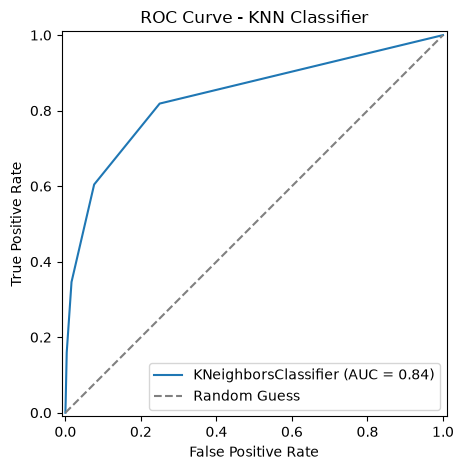

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Plot the ROC curve for the KNN classifier
plt.figure(figsize=(6, 4))
RocCurveDisplay.from_estimator(knn, X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN Classifier')
plt.legend()
plt.tight_layout()
plt.show()

### Gaussian Naive Bayes Model

In [5]:
# Train the Gaussian Naive Bayes classifier
# This model assumes each feature follows a normal distribution.
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predict water safety labels on the test set
y_pred_nb = gnb.predict(X_test)

# Evaluate the model using classification accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb * 100:.2f}%")

Naive Bayes Accuracy: 84.81%


### ROC Curve for Gaussian Naive Bayes

<Figure size 600x400 with 0 Axes>

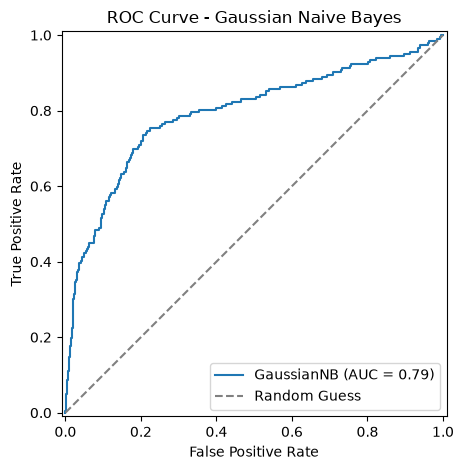

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Visualize the ROC curve for the Naive Bayes model
plt.figure(figsize=(6, 4))
RocCurveDisplay.from_estimator(gnb, X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gaussian Naive Bayes')
plt.legend()
plt.tight_layout()
plt.show()

### Logistic Regression Model

In [7]:
# Train the Logistic Regression classifier
logistic_regression = LogisticRegression(max_iter=1000)
logistic_regression.fit(X_train, y_train)

# Generate predictions for the test samples
y_pred_lr = logistic_regression.predict(X_test)

# Compute model accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr * 100:.2f}%")

Logistic Regression Accuracy: 90.88%


### Roc curve for Logistic Regression

<Figure size 600x400 with 0 Axes>

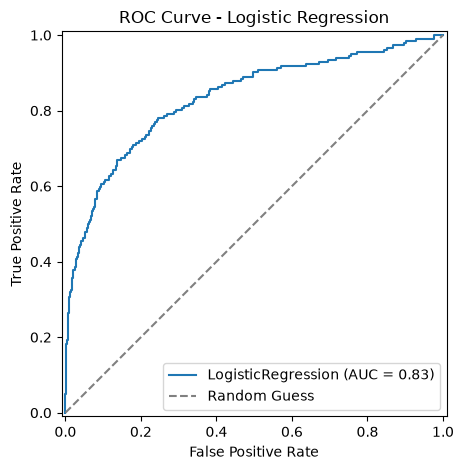

In [8]:
# Import plotting and evaluation utilities
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve for Logistic Regression
plt.figure(figsize=(6, 4))
RocCurveDisplay.from_estimator(logistic_regression, X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

Interpret the results by comparing the performance of the three classifiers using both accuracy and ROC-AUC. Then identify which model performed best and justify the conclusion.

To interpret the results, compare the three classifiers using the ROC curve and the AUC score.

- AUC values close to 1 indicate strong classification performance.
- AUC values around 0.5 indicate weak or near-random performance.

The models evaluated in this notebook are:
1. K-Nearest Neighbors (KNN)
2. Gaussian Naive Bayes
3. Logistic Regression

The next step calculates the AUC score for each classifier to compare their ability to separate safe and unsafe water samples.

### AUC scores for each model

In [9]:
# Import the AUC metric for model comparison
from sklearn.metrics import roc_auc_score

# Calculate AUC for KNN
prob_knn = knn.predict_proba(X_test)[:, 1]
auc_knn = roc_auc_score(y_test, prob_knn)

# Calculate AUC for Gaussian Naive Bayes
prob_gnb = gnb.predict_proba(X_test)[:, 1]
auc_gnb = roc_auc_score(y_test, prob_gnb)

# Calculate AUC for Logistic Regression
prob_logistic = logistic_regression.predict_proba(X_test)[:, 1]
auc_logistic_regression = roc_auc_score(y_test, prob_logistic)

# Print the final AUC comparison
print(f"AUC for KNN: {auc_knn:.3f}")
print(f"AUC for Gaussian Naive Bayes: {auc_gnb:.3f}")
print(f"AUC for Logistic Regression: {auc_logistic_regression:.3f}")

AUC for KNN: 0.838
AUC for Gaussian Naive Bayes: 0.793
AUC for Logistic Regression: 0.833


Overall, KNN and Logistic Regression are the most effective models for this classification task, while Naive Bayes performs poorly in comparison.